# Accessing Data with AI Tools

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Use an AI assistant to generate working data-access code for an API you have already
  seen, and judge whether the generated code is correct.
- Apply an AI assistant to extract structured data from an unstructured web page, where
  writing a parser by hand is tedious and brittle.
- Explain how LLMs can be called *programmatically* (API keys, tokens, SDKs) and where
  tool-use, agents, and retrieval-augmented generation fit in.
- Critically verify AI-generated code and data, and follow responsible-use practices.
:::

In [Online Data Access and APIs](Topic4.2-Online_Data_Access) you saw that the *hard*
part of getting data programmatically is rarely the idea — it is the fiddly mechanics:
digging through nested JSON with index-based access that breaks on the next molecule,
hand-constructing REST URLs, resolving names to identifiers, and parsing whatever format
the server happens to return. Those mechanics are exactly the kind of repetitive,
pattern-based coding that modern AI assistants (large language models, or LLMs) are good
at producing.

A large language model is a program trained on vast amounts of text, including a great
deal of code; given a description of a task it predicts the code that would accomplish it.
Because the patterns for calling a REST API or parsing an HTML table appear thousands of
times in its training data, an LLM is often very good at reproducing them — but it has no
way to *check* its own output against the live service, and it will sometimes produce code
that is subtly or completely wrong with total confidence.

This chapter therefore takes a deliberate stance: **the AI writes the code; you run it and
verify it.** The assistant is a coding aid for *data access*, not a data source itself —
you should never treat a number an LLM types into a chat window as authoritative. Throughout
this chapter we show each interaction as a static record: the **prompt** we gave, followed
by the **code an LLM (Claude Sonnet 4.x) generated** in response. Only the generated code
is actually executed when this book is built, so what you see is reproducible. When you
work through the exercises you will generate your own code with an assistant of your
choice and compare. As you read, pay attention to how each example *ends* — not with the
generated code, but with a check that the code did the right thing.

## Generating Data-Access Code from a Description

Recall that PubChem exposes a REST API that returns molecular properties. In Topic 4.2 we
used the `pubchempy` library, but underneath it is just HTTP requests against PubChem's
PUG REST endpoints. Suppose we want a quick table of molecular weight and lipophilicity
(XLogP) for a handful of solvents and we would rather not remember the URL scheme. We can
describe the task in plain English.

> **Prompt given to the assistant:**
>
> *I have a list of molecule names. Using the PubChem PUG REST API directly (not the
> pubchempy library), write a Python function `fetch_properties(names)` that returns a
> pandas DataFrame with columns for the molecule name, molecular weight, and XLogP.
> Handle the case where a name isn't found, and don't make more requests than necessary.*

Here is the code that Claude Sonnet 4.x generated:

In [1]:
import requests
import pandas as pd
from api_cache import safe_get   # requests.get with a cached fallback; see Topic 4.2

PUBCHEM = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

def fetch_properties(names):
    """Return a DataFrame of MolecularWeight and XLogP for each name via PubChem PUG REST."""
    records = []
    for name in names:
        url = f"{PUBCHEM}/compound/name/{name}/property/MolecularWeight,XLogP/JSON"
        r = safe_get(url)
        if r.status_code != 200:                       # name not found, etc.
            records.append({"name": name, "MolecularWeight": None, "XLogP": None})
            continue
        props = r.json()["PropertyTable"]["Properties"][0]
        records.append({
            "name": name,
            "MolecularWeight": float(props.get("MolecularWeight")),
            "XLogP": props.get("XLogP"),
        })
    return pd.DataFrame(records)

Notice that the assistant produced exactly the kind of code you would have written after
Topic 4.2 — it constructs the property endpoint, requests JSON, and reaches into
`PropertyTable -> Properties -> [0]` to pull the values. Let's run it:

In [2]:
molecules = ["ethanol", "toluene", "acetone", "benzene"]
df = fetch_properties(molecules)
df

,name,MolecularWeight,XLogP
0,ethanol,46.07,-0.1
1,toluene,92.14,2.7
2,acetone,58.08,-0.1
3,benzene,78.11,2.1


### Verify before you trust

The code ran without error and returned a tidy table — but "runs without error" is not
the same as "correct." Always check generated code against a source you trust. Here we
already have one: the `pubchempy` library from Topic 4.2.

In [3]:
import pubchempy as pcp
from api_cache import cached_json

ground_truth = cached_json(
    "pcp_ground_truth_mw",
    lambda: {m: float(pcp.get_compounds(m, "name")[0].molecular_weight) for m in molecules},
)
comparison = df.assign(pubchempy_MW=df["name"].map(ground_truth))
comparison[["name", "MolecularWeight", "pubchempy_MW"]]

,name,MolecularWeight,pubchempy_MW
0,ethanol,46.07,46.07
1,toluene,92.14,92.14
2,acetone,58.08,58.08
3,benzene,78.11,78.11


The molecular weights from our AI-generated REST code match the `pubchempy` values. That
agreement is what lets us trust the function — not the fact that an AI wrote it. When no
independent library is available, fall back on a sanity check: confirm the values have the
right magnitude, units, and sign for what you know about the system.

:::{note}
Prompting is iterative. If the first result is wrong or incomplete, refine the request
("also return the canonical SMILES", "raise an error instead of returning None") rather
than editing the generated code by hand. You will usually converge faster, and you keep a
plain-English record of what the code is supposed to do.
:::

:::{exercise}
:label: ex-dm-ai-pubchem-prop

Work with an LLM of your choice to regenerate `fetch_properties`, this time also returning
the compound's **topological polar surface area (TPSA)**. Run the new code on a few
molecules, then verify the TPSA values against `pubchempy`. Note where your assistant's
first attempt needed correction.
:::

## Extracting Data from Unstructured Web Pages

Topic 4.2 ended with a caution: not every useful data source offers a clean JSON API.
Many give you only an HTML page built for humans, and scraping it by hand means staring
at nested tags and writing brittle parsing logic. This is another place an assistant
earns its keep — and a sharper test, because there is no library like `pubchempy` to lean
on.

The [NIST Chemistry WebBook](https://webbook.nist.gov/) is a good example. Its
gas-phase thermochemistry pages list the constant-pressure heat capacity $C_p$ of a gas
as a table of $(C_p, T)$ measurements, but there is no JSON endpoint — you get HTML. Say
we want $C_p$ versus temperature as NumPy arrays for an arbitrary compound.

> **Prompt given to the assistant:**
>
> *Write a Python function `nist_gas_cp(name)` that looks up a compound by name on the
> NIST WebBook, finds the "Constant pressure heat capacity of gas" table, and returns two
> NumPy arrays — temperature in K and $C_p$ in J/mol·K — sorted by temperature. The NIST
> WebBook has no JSON API, so parse the HTML.*

Here is the code that Claude Sonnet 4.x generated:

In [4]:
import re
import requests
import numpy as np
from collections import Counter
from bs4 import BeautifulSoup

NIST = "https://webbook.nist.gov/cgi/cbook.cgi"

def _first_number(text):
    """Pull the leading number out of a cell, ignoring uncertainties like '103.7 ± 0.4'."""
    return float(re.search(r"-?\d+\.?\d*", text).group())

def nist_gas_cp(name):
    # Step 1: resolve the compound name to a NIST ID (a "C" number). The species page
    # cites other compounds too, so we take the ID that appears most often — the page's
    # own compound dominates.
    search = safe_get(NIST, params={"Name": name, "Units": "SI"})
    search.raise_for_status()
    ids = re.findall(r"ID=(C\d+)", search.text)
    if not ids:
        raise ValueError(f"Could not resolve '{name}' to a NIST ID")
    cid = Counter(ids).most_common(1)[0][0]

    # Step 2: fetch the gas-phase thermochemistry page (Mask=1)
    page = safe_get(NIST, params={"ID": cid, "Units": "SI", "Mask": 1})
    page.raise_for_status()
    soup = BeautifulSoup(page.text, "html.parser")

    # Step 3: a compound can list several "Constant pressure heat capacity of gas"
    # tables (e.g. a single measured point and a full tabulation). Keep the largest.
    headings = soup.find_all("h3", string=re.compile("Constant pressure heat capacity of gas"))
    if not headings:
        raise ValueError(f"No gas-phase Cp table for '{name}'")
    table = max((h.find_next("table") for h in headings),
                key=lambda t: len(t.find_all("tr")))

    temps, cps = [], []
    for row in table.find_all("tr")[1:]:               # skip the header row
        cells = row.find_all("td")
        if len(cells) >= 2:
            cps.append(_first_number(cells[0].get_text()))
            temps.append(_first_number(cells[1].get_text()))

    T, Cp = np.array(temps), np.array(cps)
    order = np.argsort(T)
    return T[order], Cp[order]

This is substantially more code than the PubChem example, and every step encodes an
assumption about NIST's HTML. Three details are worth highlighting, because they are
exactly the kind of thing a first draft gets wrong. The name search does not redirect to a
clean identifier in the URL; instead the species page cites *other* compounds (references,
related species) whose IDs appear alongside the one we want, so the function resolves the
name by taking the **most frequently occurring** ID — the page's own compound dominates.
A compound may also list *several* "Constant pressure heat capacity of gas" tables (a
single measured point from one study, plus a full tabulation from another), so the function
keeps the **largest** table rather than the first one it finds. And the measured values are
reported with uncertainties (`103.7 ± 0.4`), so a naive `float()` call would crash; the
`_first_number` helper extracts just the leading value. None of these is visible from the
prompt — they only surface when you run the code and read the errors.

:::{note}
The code above is *not* what the assistant produced on its first try. I had to iterate
several times with an LLM to fix bugs in the originally generated code: it grabbed the
wrong compound ID (matching a cited reference instead of the species itself), picked a
near-empty table when a fuller one existed, and failed to read cells that included an
uncertainty. Each bug surfaced only by running the code against a real page. This is the
normal rhythm of working with AI-generated code — generate, run, read the error, refine —
not a sign that something went wrong.
:::

Let's run it and look at the result:

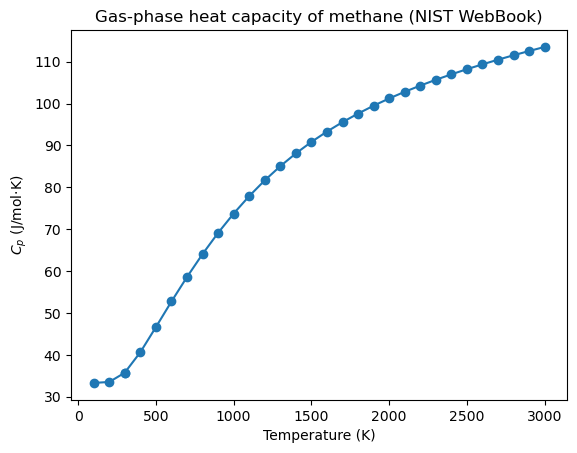

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

T, Cp = nist_gas_cp("methane")
plt.plot(T, Cp, "o-")
plt.xlabel("Temperature (K)")
plt.ylabel(r"$C_p$ (J/mol·K)")
plt.title("Gas-phase heat capacity of methane (NIST WebBook)")
plt.show()

The curve rises smoothly with temperature, as we expect for a polyatomic gas — a quick
physical sanity check that the parse worked.

:::{warning}
Web scrapers are fragile, and AI-written scrapers are no exception: they depend on the
page's current structure, which the site owner can change at any time. Verify the output
(here, the physically sensible $C_p(T)$ trend), and for real work **save the raw HTML
response alongside your parsed data** so your analysis is reproducible even if the page
later changes — the same versioning discipline introduced in Topic 4.2.
:::

:::{exercise}
:label: ex-dm-ai-nist-cp

Work with an LLM of your choice to adapt the scraper to a different compound — such as
[benzene](https://webbook.nist.gov/cgi/cbook.cgi?ID=C71432&Units=SI&Mask=1) or toluene —
and confirm the returned arrays match the values shown on the NIST page. Then ask it to
make the function also return the literature reference for each row, and check that it did
so without breaking the existing columns.
:::

## Beyond One-Shot Prompting

So far we have copied a prompt into a chat window and pasted the answer back. That is fine
for one-off code, but it does not scale — you cannot loop over a thousand compounds by
hand. To automate, you call the LLM *programmatically*, the same way you called PubChem:
over an HTTP API.

LLM providers expose an API that takes your prompt and returns generated text. Two things
differ from the public data APIs in Topic 4.2. First, they require **authentication**: you
supply an **API key** (an access token), exactly like the authenticated-API pattern from
Topic 4.2 — and as before, you load the key from an environment variable, never hard-code
it. Second, the calls **cost money**, billed per *token* — a token is roughly a few
characters of text, and you pay for both the prompt you send and the text the model
generates. A short code-generation request costs a fraction of a cent, but a loop over
thousands of inputs adds up, so it pays to be deliberate about how much text you send.
Most providers ship an official Python SDK that wraps the HTTP details:

```python
# Illustrative only — this block is NOT executed in the book.
# Running it requires a provider account, an API key, and tokens that cost money.
import os
from llm_provider import Client          # each major provider ships an official SDK

client = Client(api_key=os.environ["LLM_API_KEY"])    # load the key, never hard-code it

response = client.complete(
    model="<a-current-model>",
    prompt="Write a Python function that fetches the boiling point of a compound from PubChem.",
)
print(response.text)
```

Once you can call an LLM from code, richer patterns open up:

- **Tool use / function calling** — instead of *describing* an API, you register your
  `fetch_properties` function with the model and let it decide when to call it, so the
  model retrieves live data itself rather than guessing.
- **Agents** — a model that plans a multi-step task, calling tools in a loop until the
  job is done.
- **Retrieval-augmented generation (RAG)** — attach your own document corpus (lab
  notebooks, datasheets, papers) so the model answers from *your* data instead of its
  training set.

These are beyond the scope of this course, but the references below are good starting
points. The common thread is that the LLM stops being a one-shot code generator and
becomes a component you wire into a larger program — which makes the verification habit
from this chapter more important, not less, because there is no longer a human reading
each answer before it is used.

:::{tip}
The quality of generated code depends heavily on the prompt. The prompts in this chapter
work because they state the *inputs*, the *desired output* (a DataFrame, two NumPy arrays),
the *constraints* ("use the REST API directly, not pubchempy"), and the *edge cases*
("handle a name that isn't found"). Vague requests produce vague code; specifying the
shape of the answer you want is the single most effective habit.
:::

:::{exercise}
:label: ex-dm-ai-llm-tool

Work with an LLM of your choice to create a small *programmatic* prompting tool: a script
that sends a prompt to a provider's API and prints the response (note that this requires
an API key and may cost a small amount in tokens). Use it to regenerate one of the
data-access functions from this chapter, then verify the result as we did above.
:::

## Summary

- AI assistants are most useful for data access as **code generators**: describe the data
  you want in plain English and let the assistant write the request/parse logic for an API
  or a web page.
- They shine on the tedious, brittle parts — nested JSON, REST URL construction, and HTML
  scraping where no clean API exists (e.g., NIST WebBook heat-capacity tables).
- Calling an LLM programmatically (API key, tokens, an SDK) unlocks automation and the
  more advanced tool-use, agent, and RAG patterns.

### Verification and Responsible Use

Generated code and AI-reported data can be confidently *wrong*: a model may invent an API
endpoint, mislabel a column, or hallucinate a numeric value outright. Treat every result
as unverified until you check it against a trusted source — as we checked the PubChem code
against `pubchempy`, and the NIST curve against physical expectation. For reproducibility,
record the model and library versions you used, save raw API/HTML responses, and note in
your work where AI assistance was involved and what you did to validate it. Finally, be
deliberate about *what you send* to an external tool: do not paste confidential,
export-controlled, or student/FERPA-protected data into a third-party service, and follow
your institution's guidance on which tools are approved for which kinds of data.

## Additional Reading

- [NIST Chemistry WebBook](https://webbook.nist.gov/) — gas-phase thermochemistry data used above.
- [PubChem PUG REST documentation](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest) — the API behind `fetch_properties`.
- [Requests documentation](https://requests.readthedocs.io/) and [Beautiful Soup documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) — the HTTP and HTML-parsing libraries used by the generated code.
- Your LLM provider's prompt-engineering and API documentation — for writing effective prompts and making programmatic calls.